In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Loading the Dataset usinf pd.read_csv
### Note:
the data is seperated with ';'  not the default ','

In [2]:
df = pd.read_csv('student/student-mat.csv', delimiter = ';')

In [3]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


# Exploring The Dataset

In [4]:
df.shape # Returning the shape of the Dataset in tems of (no. of records, no. of columns)

(395, 33)

In [5]:
df.columns # Veiwing the different columns available in the Dataset

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [6]:
df.dtypes # Another way to check the data types the column will take as a record

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

## Cheking For Null Value Availability

In [7]:
df.isnull().sum(axis = 'rows') # way to check is there are any null values available in the dataset

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [8]:
df.info() # Concise value of the Dataset

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

## Checking For Duplicates

In [9]:
df.duplicated().sum() # .duplocayed function is used for checking if any duplicate values exists - combining with .sum() to check if any Diplocates records exists

np.int64(0)

# Data Analysis

In [10]:
final_grade_avg = df['G3'].mean() # Getting the Average Final Grade (G3)
float(final_grade_avg)

10.415189873417722

In [11]:
int(((df['G1'] > 15) | (df['G2'] > 15) | (df['G3'] > 15)).sum()) # gives us the number of student who have scored above 15 in one or more grades

53

In [12]:
correlation = df[['studytime','G1','G2','G3']].corr()
correlation['studytime'] # This give us the view of how each grade is correlated with studytime

studytime    1.000000
G1           0.160612
G2           0.135880
G3           0.097820
Name: studytime, dtype: float64

### We Know that closer the correlation value to 1 higher the correlation and colser the value to 0 there isint a lot of Correlation
### From the above we can see that there is minimal Correlation of grades with respect to study time since the values are < 2

In [13]:
avg = df.groupby('sex')[['G1', 'G2', 'G3']].mean() # Grouping by the Gender then getting the Average for each grade
avg

,G1,G2,G3
sex,,,
F,10.620192,10.389423,9.966346
M,11.229947,11.074866,10.914439


### From the above we can clearly see that the Males gender performs better than Females on average for all the grades

# Plotting Graphs

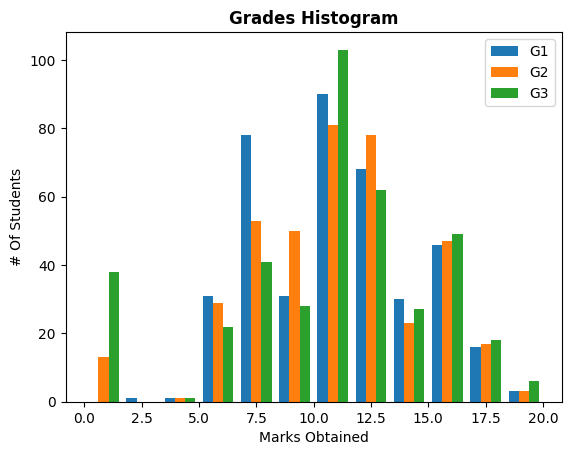

In [14]:
plt.hist(df[['G1','G2','G3']],bins = 12) # Creating a histogram of grades with 12 bins for each grade
plt.legend(['G1','G2','G3']) # Specifying the legend for better understanding
plt.title('Grades Histogram', fontweight = 'bold') # Giving title for the Histogram
plt.xlabel('Marks Obtained') # Giving the x & y axis their labels
plt.ylabel('# Of Students')
plt.show() # displaying the plot

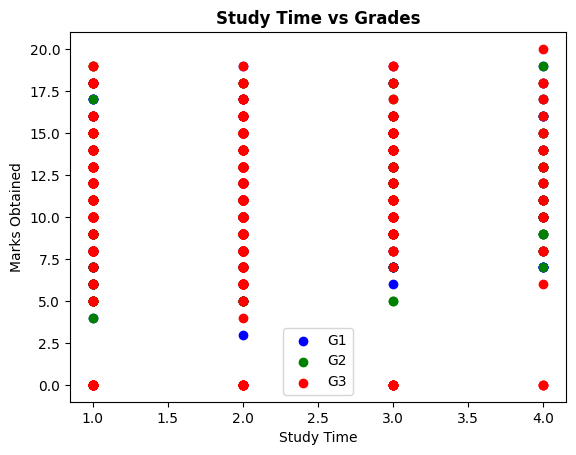

In [15]:
plt.scatter(df['studytime'],df['G1'],color='blue') # Creatting scatter plot for each grades with different colors
plt.scatter(df['studytime'],df['G2'],color='green')
plt.scatter(df['studytime'],df['G3'],color='red')
plt.legend(['G1','G2','G3']) # Creating a legend for better understanding
plt.title('Study Time vs Grades', fontweight = 'bold') # Giving title for the plot
plt.xlabel('Study Time') # Giving the x & y axis their respective labels
plt.ylabel('Marks Obtained')
plt.show()

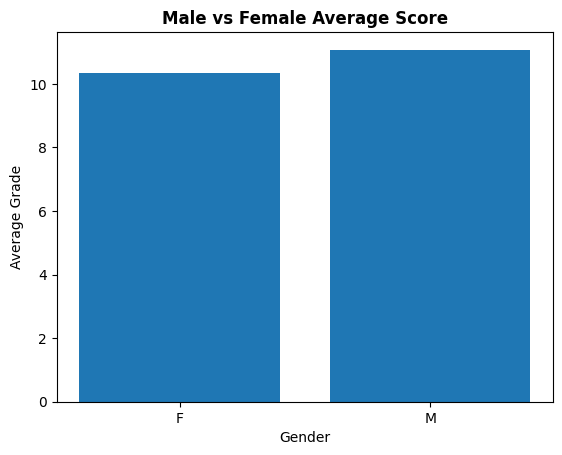

In [16]:
plt.bar(avg.index,avg.mean(axis = 'columns')) # createing the bar chart 
plt.xlabel('Gender') # Giving x & y axis their labels
plt.ylabel('Average Grade')
plt.title('Male vs Female Average Score', fontweight = 'bold') # Giving the plot its title
plt.show()